# Задача 1. EDA существующих продаж

**Цель:** разобраться, что именно находится в `base.xlsx`, определить покупку, заказ и покупателя, исследовать пакеты, повторные покупки, продуктовые сочетания, динамику и аномалии.

Главный принцип: мы отдельно отмечаем факты из данных и предположения, которые нужно подтвердить у бизнеса.

## 1. Подключаем библиотеки и загружаем данные

Положите `base.xlsx` в ту же папку, что и ноутбук. Для уже выполненной версии ниже указан путь к приложенному файлу.

In [4]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)

# Путь относительно папки notebooks/
DATA_PATH = Path("../data/raw/base.xlsx")

df = pd.read_excel(
    DATA_PATH,
    sheet_name="Данные"
)

df = df.rename(columns={
    "Номер студента": "student_id",
    "Сумма": "amount",
    "Курс": "course",
    "Время": "timestamp",
})

df.head()

,student_id,amount,course,timestamp
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06


## 2. Первичный обзор

Сначала проверяем размер таблицы, типы полей и период наблюдения.

In [5]:
print(f"Строк: {len(df)}")
print(f"Покупателей: {df['student_id'].nunique()}")
print(f"Курсов: {df['course'].nunique()}")
print(f"Период: {df['timestamp'].min()} — {df['timestamp'].max()}")
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all").T)

Строк: 795
Покупателей: 606
Курсов: 18
Период: 2026-08-04 09:08:31 — 2026-09-10 06:09:12


,dtype
student_id,int64
amount,float64
course,object
timestamp,datetime64[ns]


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
student_id,795.0,NaN,NaN,NaN,302.745912,1.0,153.5,303.0,451.5,606.0,175.159448
amount,795.0,NaN,NaN,NaN,7427.259962,500.0,6490.0,7475.0,8950.0,19350.0,1827.497664
course,795,18,Аналитика про,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,795,NaN,NaN,NaN,2026-08-24 00:05:47.483018752,2026-08-04 09:08:31,2026-08-10 16:56:42,2026-08-24 15:05:04,2026-09-04 01:49:25.500000,2026-09-10 06:09:12,NaN


## 3. Аудит качества данных

Проверяем пропуски, полные дубликаты, некорректные суммы и названия курсов. Необычная сумма сама по себе ещё не ошибка: это может быть скидка, пакет, рассрочка или доплата.

In [6]:
quality = pd.Series({
    "Пропуски student_id": df['student_id'].isna().sum(),
    "Пропуски amount": df['amount'].isna().sum(),
    "Пропуски course": df['course'].isna().sum(),
    "Пропуски timestamp": df['timestamp'].isna().sum(),
    "Полные дубликаты": df.duplicated().sum(),
    "Нулевые/отрицательные суммы": (df['amount'] <= 0).sum(),
})
display(quality.to_frame("Количество"))
display(pd.DataFrame({"course": sorted(df['course'].unique())}))

,Количество
Пропуски student_id,0
Пропуски amount,0
Пропуски course,0
Пропуски timestamp,0
Полные дубликаты,0
Нулевые/отрицательные суммы,0


,course
0,AI агенты
1,Backend про
2,Backend старт
3,Data Engenering
4,Data Science
5,ML про
6,ML старт
7,АВ тестам
8,Алгоритмы
9,Алгоритмы про


In [7]:
# Кандидаты на ручную проверку, но не строки для автоматического удаления
suspicious_amounts = df[(df['amount'] <= 2_500) | (df['amount'] >= 15_000)]
suspicious_amounts.sort_values(['amount', 'timestamp'])

,student_id,amount,course,timestamp
23,477,500.0,Теория вероятностей,2026-08-06 14:52:49
134,462,500.0,Алгоритмы старт,2026-08-09 16:45:22
486,437,1000.0,AI агенты,2026-08-30 16:16:42
714,366,2237.5,AI агенты,2026-09-06 15:18:37
715,366,2237.5,ML про,2026-09-06 15:18:37
716,366,2237.5,ML старт,2026-09-06 15:18:37
717,366,2237.5,Алгоритмы старт,2026-09-06 15:18:37
719,55,2237.5,AI агенты,2026-09-06 15:35:13
720,23,2237.5,ML старт,2026-09-06 15:39:44
721,51,2237.5,ML про,2026-09-06 15:46:24


### Вывод по качеству

- пропусков, полных дубликатов и неположительных сумм нет;
- `Data Engenering` похоже на опечатку, но без справочника продуктов не переименовываем;
- необычные суммы сохраняем и передаём на проверку;
- в данных нет `order_id`, статуса платежа, возвратов, валюты и типа платежа.

## 4. Что считать покупкой, заказом и покупателем

- **Покупатель** — уникальный `student_id`.
- **Позиция покупки** — одна строка и один курс.
- **Заказ** — все строки одного студента с абсолютно одинаковым временем.
- **Пакет** — заказ, содержащий несколько курсов.

Это рабочее допущение. Совпадение пользователя и времени с точностью до секунды — сильный признак одной оплаты, но окончательно подтвердить правило можно только по платёжной системе.

In [8]:
orders = (
    df.groupby(['student_id', 'timestamp'], as_index=False)
      .agg(
          order_revenue=('amount', 'sum'),
          item_count=('course', 'size'),
          course_count=('course', 'nunique'),
          courses=('course', lambda x: ' + '.join(sorted(set(x)))),
      )
      .sort_values(['timestamp', 'student_id'])
)

summary = pd.Series({
    "Строк-позиций": len(df),
    "Заказов": len(orders),
    "Уникальных покупателей": orders['student_id'].nunique(),
    "Выручка, ₽": orders['order_revenue'].sum(),
    "Средний чек, ₽": orders['order_revenue'].mean(),
    "Медианный чек, ₽": orders['order_revenue'].median(),
    "Многопозиционных заказов": (orders['item_count'] > 1).sum(),
})
display(summary.to_frame("Значение").round(2))

,Значение
Строк-позиций,795.00
Заказов,628.00
Уникальных покупателей,606.00
"Выручка, ₽",5904671.67
"Средний чек, ₽",9402.34
"Медианный чек, ₽",8950.00
Многопозиционных заказов,153.00


Важно: считать 795 строк как 795 заказов нельзя. Это занизит средний чек, потому что несколько строк могут относиться к одному пакету.

## 5. Пакетные заказы

Смотрим распределение числа курсов внутри заказа и вклад пакетов в выручку.

In [9]:
display(orders['item_count'].value_counts().sort_index().rename_axis('Курсов в заказе').to_frame('Заказов'))

package_summary = (
    orders.assign(order_type=np.where(orders['item_count'] > 1, 'Пакет', 'Один курс'))
          .groupby('order_type')
          .agg(orders=('student_id', 'size'),
               revenue=('order_revenue', 'sum'),
               avg_order_value=('order_revenue', 'mean'))
)
package_summary['revenue_share'] = package_summary['revenue'] / package_summary['revenue'].sum()
display(package_summary.round(3))

,Заказов
Курсов в заказе,
1,475
2,145
3,4
4,2
5,2


,orders,revenue,avg_order_value,revenue_share
order_type,,,,
Один курс,475,3785638.67,7969.766,0.641
Пакет,153,2119033.00,13849.889,0.359


**Вывод:** 153 заказа из 628 содержат несколько курсов. Они дали около 35,9% общей выручки. Средний чек пакета заметно выше, поэтому пакеты — важная часть продаж.

## 6. Повторные покупки

Повторным считаем второй и последующий восстановленный заказ одного покупателя.

In [10]:
orders = orders.sort_values(['student_id', 'timestamp']).copy()
orders['order_number'] = orders.groupby('student_id').cumcount() + 1
orders['is_repeat'] = orders['order_number'] > 1

buyer_order_counts = orders.groupby('student_id').size()
display(buyer_order_counts.value_counts().sort_index().rename_axis('Заказов у покупателя').to_frame('Покупателей'))

repeat_buyers = (buyer_order_counts >= 2).sum()
repeat_revenue = orders.loc[orders['is_repeat'], 'order_revenue'].sum()
print(f"Покупателей с повтором: {repeat_buyers} ({repeat_buyers / len(buyer_order_counts):.1%})")
print(f"Повторных заказов после первого: {orders['is_repeat'].sum()}")
print(f"Доля выручки повторных заказов: {repeat_revenue / orders['order_revenue'].sum():.1%}")

,Покупателей
Заказов у покупателя,
1,586
2,19
4,1


Покупателей с повтором: 20 (3.3%)
Повторных заказов после первого: 22
Доля выручки повторных заказов: 3.2%


**Вывод:** повторную покупку сделали 20 покупателей, или 3,3%. Повторные заказы дали около 3,2% выручки. История длится только 38 дней, поэтому это не полноценная оценка retention или LTV.

## 7. Анализ продуктов

In [11]:
course_metrics = (
    df.groupby('course', as_index=False)
      .agg(
          positions=('student_id', 'size'),
          buyers=('student_id', 'nunique'),
          revenue=('amount', 'sum'),
          avg_amount=('amount', 'mean'),
          median_amount=('amount', 'median'),
          price_variants=('amount', 'nunique'),
      )
      .sort_values('revenue', ascending=False)
)
display(course_metrics.round(2))

,course,positions,buyers,revenue,avg_amount,median_amount,price_variants
11,Аналитика про,93,92,740941.50,7967.11,8450.0,14
5,ML про,90,90,715110.00,7945.67,8450.0,9
0,AI агенты,91,90,711673.00,7820.58,8450.0,14
12,Аналитика старт,91,91,641616.50,7050.73,7471.5,21
10,Алгоритмы старт,88,88,529851.68,6021.04,4995.0,19
6,ML старт,80,80,523278.33,6540.98,6490.0,22
1,Backend про,55,55,438342.50,7969.86,8450.0,14
9,Алгоритмы про,35,35,268409.00,7668.83,7475.0,10
2,Backend старт,39,39,263396.66,6753.76,6490.0,12
8,Алгоритмы,30,30,209482.50,6982.75,5750.0,16


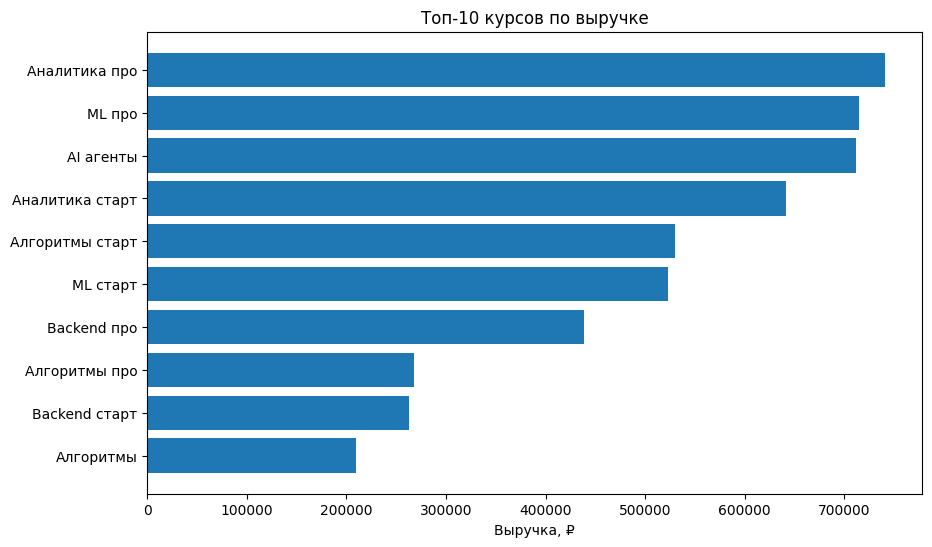

In [12]:
top_courses = course_metrics.head(10).sort_values('revenue')
plt.figure(figsize=(10, 6))
plt.barh(top_courses['course'], top_courses['revenue'])
plt.title('Топ-10 курсов по выручке')
plt.xlabel('Выручка, ₽')
plt.ylabel('')
plt.show()

Лидеры по выручке: «Аналитика про», «ML про» и «AI агенты». Но это ещё не означает, что их реклама эффективнее: у нас нет рекламных затрат и источников покупателей.

## 8. Сочетания курсов

Считаем, какие пары курсов встречались у одного покупателя. Это могут быть пакеты или покупки в разные даты.

In [13]:
pairs = []
for student_id, group in df[['student_id', 'course']].drop_duplicates().groupby('student_id'):
    pairs.extend(combinations(sorted(group['course']), 2))

course_pairs = (
    pd.DataFrame(pairs, columns=['course_1', 'course_2'])
      .value_counts()
      .rename('buyers')
      .reset_index()
)
course_pairs.head(15)

,course_1,course_2,buyers
0,ML старт,Алгоритмы старт,24
1,Аналитика про,Аналитика старт,24
2,AI агенты,ML про,20
3,ML про,ML старт,15
4,Алгоритмы старт,Аналитика старт,11
5,Backend старт,Алгоритмы старт,10
6,Алгоритмы про,Алгоритмы старт,10
7,Backend про,Backend старт,8
8,AI агенты,Backend про,7
9,AI агенты,Аналитика про,5


Самые частые пары: «ML старт + Алгоритмы старт» и «Аналитика про + Аналитика старт» — по 24 покупателя; «AI агенты + ML про» — 20. Чтобы отличить готовые пакеты от органических сочетаний, нужен справочник предложений.

## 9. Динамика продаж и выручки

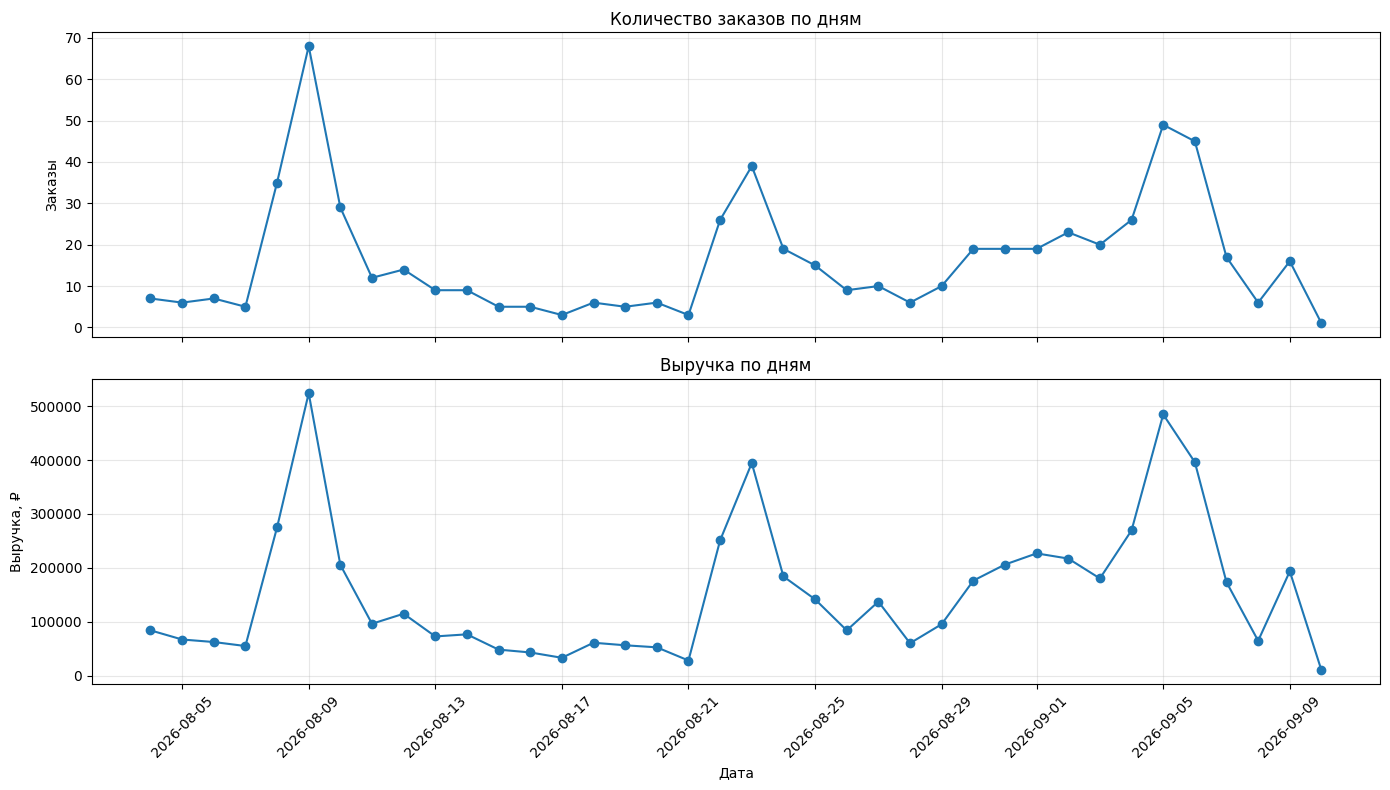

In [15]:
daily = (
    orders.assign(date=orders["timestamp"].dt.floor("D"))
          .groupby("date", as_index=False)
          .agg(
              orders=("student_id", "size"),
              buyers=("student_id", "nunique"),
              revenue=("order_revenue", "sum")
          )
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    daily["date"],
    daily["orders"],
    marker="o"
)
axes[0].set_title("Количество заказов по дням")
axes[0].set_xlabel("")
axes[0].set_ylabel("Заказы")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    daily["date"],
    daily["revenue"],
    marker="o"
)
axes[1].set_title("Выручка по дням")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Выручка, ₽")
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
daily.nlargest(10, 'revenue')

,date,orders,buyers,revenue
5,2026-08-09,68,68,524091.67
32,2026-09-05,49,48,484684.00
33,2026-09-06,45,45,396075.00
19,2026-08-23,39,39,394495.00
4,2026-08-08,35,35,275015.00
31,2026-09-04,26,26,269585.00
18,2026-08-22,26,26,251150.00
28,2026-09-01,19,19,226880.00
29,2026-09-02,23,23,217280.00
27,2026-08-31,19,19,206188.00


## 10. Поиск аномальных дней

Используем устойчивый z-score на основе медианы и MAD. Дни с абсолютным значением больше 3 помечаем как аномальные. Это способ найти всплеск, а не доказать его причину.

In [17]:
for metric in ['orders', 'revenue']:
    median = daily[metric].median()
    mad = (daily[metric] - median).abs().median()
    daily[f'{metric}_robust_z'] = 0 if mad == 0 else 0.6745 * (daily[metric] - median) / mad

daily['is_anomaly'] = (
    (daily['orders_robust_z'].abs() > 3) |
    (daily['revenue_robust_z'].abs() > 3)
)
daily[daily['is_anomaly']]

,date,orders,buyers,revenue,orders_robust_z,revenue_robust_z,is_anomaly
5,2026-08-09,68,68,524091.67,6.407750,4.332679,True
19,2026-08-23,39,39,394495.00,3.147667,2.990858,True
32,2026-09-05,49,48,484684.00,4.271833,3.924659,True
33,2026-09-06,45,45,396075.00,3.822167,3.007217,True


Аномальные всплески обнаружены 9 и 23 августа, 5 и 6 сентября. Проверить гипотезы о запуске, скидке или рекламном посте нельзя без календаря маркетинговых активностей.

10 сентября — неполный день: данные заканчиваются в 06:09. Его падение нельзя интерпретировать как ухудшение продаж.

## 11. День недели и время покупки

,weekday,orders,revenue
0,Monday,87,802411.00
1,Tuesday,65,674850.00
2,Wednesday,73,733375.00
3,Thursday,53,515615.00
4,Friday,49,489615.00
5,Saturday,125,1154719.00
6,Sunday,176,1534086.67


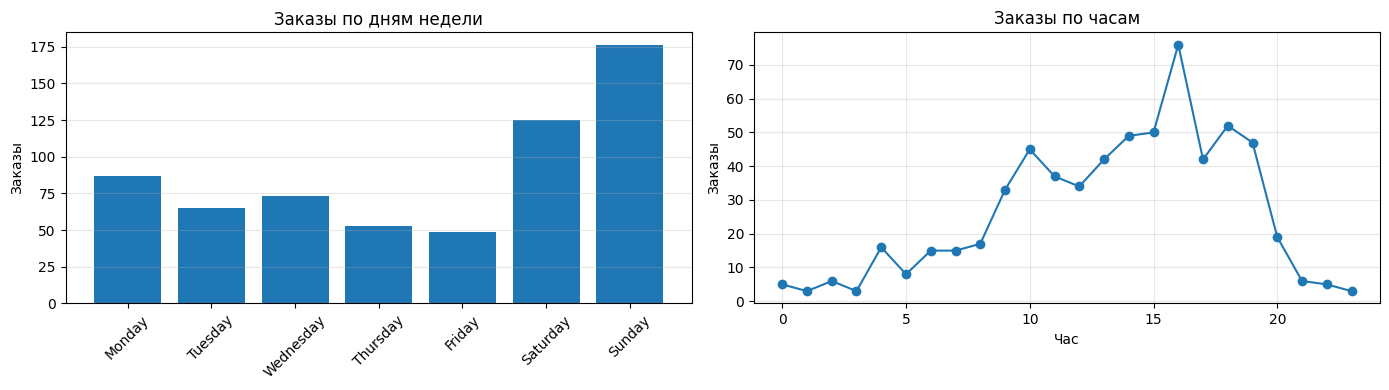

In [19]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday = (
    orders.assign(weekday=orders["timestamp"].dt.day_name())
          .groupby("weekday", as_index=False)
          .agg(
              orders=("student_id", "size"),
              revenue=("order_revenue", "sum")
          )
          .set_index("weekday")
          .reindex(weekday_order)
          .reset_index()
)

display(weekday)

hourly = (
    orders.assign(hour=orders["timestamp"].dt.hour)
          .groupby("hour", as_index=False)
          .agg(
              orders=("student_id", "size"),
              revenue=("order_revenue", "sum")
          )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Заказы по дням недели
axes[0].bar(
    weekday["weekday"],
    weekday["orders"]
)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Заказы по дням недели")
axes[0].set_xlabel("")
axes[0].set_ylabel("Заказы")
axes[0].grid(axis="y", alpha=0.3)

# Заказы по часам
axes[1].plot(
    hourly["hour"],
    hourly["orders"],
    marker="o"
)
axes[1].set_title("Заказы по часам")
axes[1].set_xlabel("Час")
axes[1].set_ylabel("Заказы")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

В выборке больше заказов по выходным и во второй половине дня. Но период короткий, а отдельные всплески сильно влияют на результат. Поэтому это наблюдение, а не устойчивый поведенческий вывод.

## 12. Что можно и нельзя ответить

### Можно

- посчитать выручку, позиции, восстановленные заказы и покупателей;
- изучить чек, пакеты, повторы и сочетания курсов;
- сравнить продукты и найти временные всплески;
- сформировать гипотезы для дальнейшей проверки.

### Нельзя

- определить источник покупателя;
- посчитать CAC, CPA, конверсию и ROMI;
- доказать влияние конкретной рекламы на всплеск;
- учесть возвраты и отмены;
- оценить долгосрочный LTV и сезонность;
- точно классифицировать необычные суммы.

## Итоговый вывод

В таблице 628 восстановленных заказов от 606 покупателей на сумму 5,90 млн ₽. Пакеты дают около 36% выручки, а повторные заказы — около 3%. Продажи идут выраженными волнами, но их причины невозможно связать с маркетингом без журнала рекламных активностей.

Следующий важный шаг для бизнеса — начать сохранять `order_id`, состав и полную цену заказа, статус платежа, скидку, источник, кампанию и рекламные затраты.